In [ ]:
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 9.4 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.52.0
    Uninstalling shap-0.52.0:
      Successfully uninstalled shap-0.52.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("autumn_2024.csv")      # change season accordingly

df = df.dropna().reset_index(drop=True)

# =====================================================
# Outcome
# =====================================================

Y = df["wdLoad"].values

# =====================================================
# Treatments
# =====================================================

T = df[
    [
        "temp",
        "rh"
    ]
].values

# =====================================================
# Confounders
# =====================================================

X = df[
    [
        "hour",
        "weekend",
        "holiday",
        "festival",
        "office_hours"
    ]
].values

# =====================================================
# Causal Forest
# =====================================================

model = CausalForestDML(

    model_y=RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    model_t=MultiOutputRegressor(

        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )

    ),

    n_estimators=500,

    min_samples_leaf=10,

    random_state=42

)

# =====================================================
# Train
# =====================================================

model.fit(
    Y,
    T,
    X=X
)

# =====================================================
# Marginal Effects
# =====================================================

effects = model.const_marginal_effect(X)

temp_effect = effects[:,0]

rh_effect = effects[:,1]

# =====================================================
# Average Treatment Effect
# =====================================================

print()

print("ATE (Temp → Load):",temp_effect.mean())

print("ATE (RH → Load):",rh_effect.mean())


ATE (Temp → Load): 7.59848692990713
ATE (RH → Load): 0.847364770213752


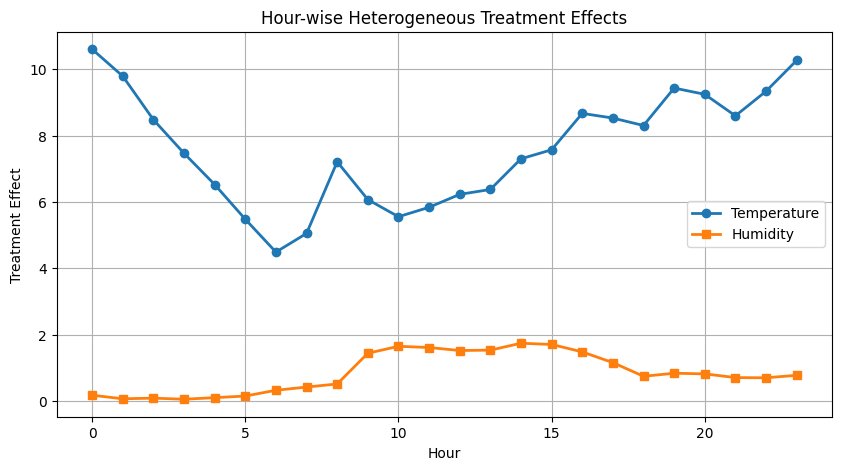

In [ ]:
plot_df = pd.DataFrame({

    "hour":df["hour"],

    "temp_effect":temp_effect,

    "rh_effect":rh_effect

})

hour_effect = plot_df.groupby("hour")[

    [
        "temp_effect",
        "rh_effect"
    ]

].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(

    hour_effect["hour"],

    hour_effect["temp_effect"],

    marker="o",

    linewidth=2,

    label="Temperature"

)

plt.plot(

    hour_effect["hour"],

    hour_effect["rh_effect"],

    marker="s",

    linewidth=2,

    label="Humidity"

)

plt.xlabel("Hour")

plt.ylabel("Treatment Effect")

plt.title("Hour-wise Heterogeneous Treatment Effects")

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("autumn_2024.csv")

df = df.dropna().reset_index(drop=True)

# =====================================================
# Outcome
# =====================================================

Y = df["wdLoad"].values

# =====================================================
# Treatments
# =====================================================

T = df[
    [
        "weekend",
        "holiday",
        "festival",
        "office_hours"
    ]
].values

# =====================================================
# Confounders
# =====================================================

X = df[
    [
        "temp",
        "rh",
        "hour"
    ]
].values

# =====================================================
# CAUSAL FOREST
# =====================================================

model = CausalForestDML(

    model_y=RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    model_t=MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    ),

    n_estimators=500,
    min_samples_leaf=10,
    random_state=42
)

# =====================================================
# TRAIN
# =====================================================

model.fit(
    Y,
    T,
    X=X
)

print("Model trained successfully!")

# =====================================================
# MARGINAL EFFECTS
# =====================================================

effects = model.const_marginal_effect(X)

print("Effect Matrix Shape :", effects.shape)

weekend_effect = effects[:,0]
holiday_effect = effects[:,1]
festival_effect = effects[:,2]
office_effect = effects[:,3]

# =====================================================
# ATE
# =====================================================

print("\n========== Average Treatment Effects ==========")

print("ATE (Weekend → Load):      ", weekend_effect.mean())

print("ATE (Holiday → Load):      ", holiday_effect.mean())

print("ATE (Festival → Load):     ", festival_effect.mean())

print("ATE (Office Hours → Load): ", office_effect.mean())

Model trained successfully!
Effect Matrix Shape : (5856, 4)

========== Average Treatment Effects ==========
ATE (Weekend → Load):       -59.85822568836151
ATE (Holiday → Load):       -22.799342203231493
ATE (Festival → Load):      7.422750953788502
ATE (Office Hours → Load):  21.9430373015393


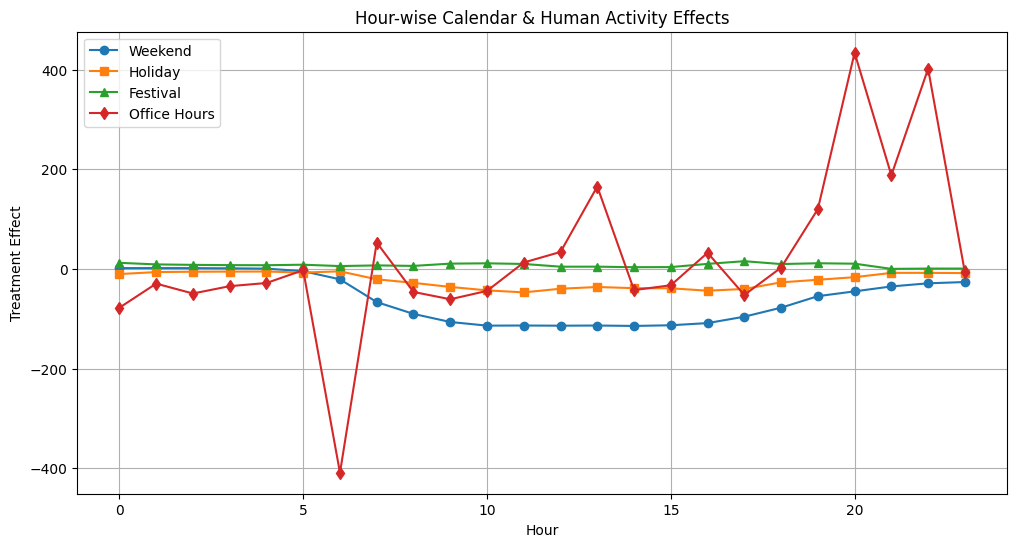

In [ ]:
plot_df = pd.DataFrame({

    "hour":df["hour"],

    "Weekend":weekend_effect,

    "Holiday":holiday_effect,

    "Festival":festival_effect,

    "Office":office_effect

})

hour_effect = plot_df.groupby("hour").mean()

plt.figure(figsize=(12,6))

plt.plot(hour_effect.index,
         hour_effect["Weekend"],
         marker="o",
         label="Weekend")

plt.plot(hour_effect.index,
         hour_effect["Holiday"],
         marker="s",
         label="Holiday")

plt.plot(hour_effect.index,
         hour_effect["Festival"],
         marker="^",
         label="Festival")

plt.plot(hour_effect.index,
         hour_effect["Office"],
         marker="d",
         label="Office Hours")

plt.grid(True)

plt.legend()

plt.xlabel("Hour")

plt.ylabel("Treatment Effect")

plt.title("Hour-wise Calendar & Human Activity Effects")

plt.show()